# Tutorial 18 — bcc iron: Berry curvature and anomalous Hall conductivity

The waw-native reimagining of Wannier90 tutorial 18 (the postw90 `berry` module). Using the same 18 spinor MLWFs of ferromagnetic bcc Fe, we compute the **Berry curvature** along a k-path and the **anomalous Hall conductivity** (AHC) as a function of Fermi energy — the full WYSV06 $J_0+J_1+J_2$ formula with the Wannier position operator (`waw.analysis.topology`, `waw.core.compute_position_r`).

The AHC needs a **dense** k-mesh to converge; this is where waw's multi-core batched Berry-curvature evaluation (`waw.set_num_threads`) matters — a 25³ mesh runs in seconds.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Converged SOC DFT and Wannierisation
Identical to notebook 17 (same converged noncollinear+SOC Fe, 18 spinor MLWFs).

In [2]:
from ase.build import bulk
import torch
from waw.interfaces.ase.structure import real_lattice, recip_lattice, band_path_segments

atoms = bulk('Fe', 'bcc', a=2.8699)          # 5.4235 bohr
MP_GRID = (4, 4, 4)
WORK = HERE / 'runs' / 'fe'

# noncollinear + spin-orbit; PseudoDojo fully-relativistic Fe pseudo
SOC = dict(noncolin=True, lspinorb=True)
SOC['starting_magnetization(1)'] = 0.4
SOC.update(occupations='smearing', smearing='cold', degauss=0.02)

# scf (16^3) -> waw .nnkp (spinor) -> nscf (4^3, 36 bands) -> pw2wannier90 SCDM
# 8 semicore 3s3p spinor bands are excluded; 28 -> 18 spinor MLWFs.
ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'fe',
    ecutwfc=60, scf_kpts=(16, 16, 16), nbnd=36, num_wann=18,
    exclude_bands=list(range(1, 9)),
    scdm_entanglement='erfc', scdm_mu=25.0, scdm_sigma=5.0,
    system_extra=SOC, pseudopotentials={'Fe': 'Fe-sp_r.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES, write_spn=True,
    rerun_scf=False,          # reuse a completed SCF in runs/fe/ if present
)

result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'], nw=18,
    outer_window=(8.0, 70.0), frozen_window=(8.0, 19.8),
    n_restarts=2, dis_n_iter=1000, n_iter=3000, verbose=False,
)
E_FERMI = ov['fermi_energy']                 # eV, read from the SCF by qe.py
print(f'Omega_I = {result.dis.omega_i * BOHR_TO_ANG**2:.4f} Ang^2  '
      f'(18 spinor MLWFs from 28 bands; W90 tut17/18 4x4x4: ~9.17); '
      f'E_F = {E_FERMI:.3f} eV')

# ASE's standard bcc high-symmetry path, as parse_kpoint_path-style segments
KPATH = band_path_segments(atoms)
REAL = real_lattice(atoms)
RECIP = recip_lattice(atoms)

Omega_I = 9.3225 Ang^2  (18 spinor MLWFs from 28 bands; W90 tut17/18 4x4x4: ~9.17); E_F = 17.630 eV


### Interpolated bands against the ab-initio reference
The Wannier bands (lines) over a non-self-consistent `calculation='bands'` run
along the same path (points), with the disentanglement windows shaded and
everything referred to $E_F$. Inside the frozen window the interpolation must
reproduce the ab-initio bands exactly; the printed deviation on the
Wannierization mesh itself is the quantitative form of the same statement.

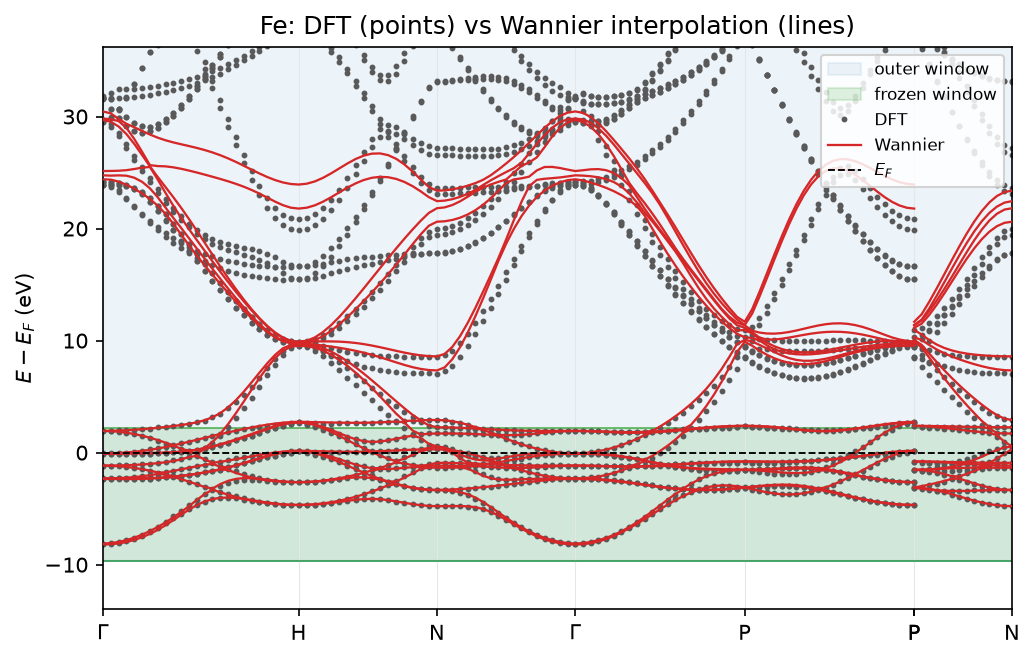

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 629 states


In [3]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = E_FERMI
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'fe', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=(8.0, 70.0), frozen_window=(8.0, 19.8), fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('Fe: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=(8.0, 19.8), fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


### 2. Wannier position operator and Berry curvature along ASE's standard path
$AA(R) = \langle 0n|r|Rm\rangle$ comes from the finite-difference Berry connection of the overlaps; the occupied-band Berry curvature $J_0+J_1+J_2$ is evaluated at $E_F$.

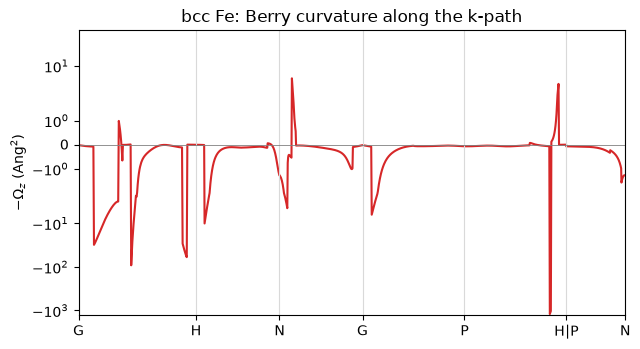

In [4]:
from waw.core.hamiltonian import compute_position_r
from waw.analysis.topology import (wannier_interpolated_curvature,
                                   anomalous_hall_conductivity)
from waw.analysis.kpath import parse_kpoint_path, build_kpath
from waw.units import EV_TO_HARTREE, to_si_units

AA_R = compute_position_r(result.m_tilde, result.wdata.wb,
                          result.wdata.bvecs, result.wdata.kpts, MP_GRID, REAL)
CELL_VOLUME_BOHR3 = abs(np.linalg.det(REAL))

segments = parse_kpoint_path(KPATH)
kpath = build_kpath(segments, RECIP, n_points=200)
curv = wannier_interpolated_curvature(result.hr, AA_R, RECIP, REAL,
                                      kpath.kpts, E_FERMI * EV_TO_HARTREE)[:, 0, :]
curv_z = -curv[:, 2] * BOHR_TO_ANG**2      # -Omega_z, postw90's plotted sign, Ang^2

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(kpath.dists, curv_z, 'C3')
for x in kpath.tick_dists:
    ax.axvline(x, color='0.85', lw=0.8)
ax.axhline(0.0, color='0.5', lw=0.6)
ax.set_xticks(kpath.tick_dists); ax.set_xticklabels(kpath.tick_labels)
ax.set_ylabel(r'$-\Omega_z$ (Ang$^2$)'); ax.set_yscale('symlog')
ax.set_xlim(kpath.dists[0], kpath.dists[-1])
ax.set_title('bcc Fe: Berry curvature along the k-path')
plt.tight_layout(); plt.show()

Sharp Berry-curvature spikes appear where spin–orbit coupling opens avoided crossings near $E_F$ — these hot-spots dominate the anomalous Hall effect.

### 3. Anomalous Hall conductivity vs Fermi energy
The AHC is the Brillouin-zone average of the occupied-band curvature, in S/cm. bcc Fe's AHC is famously hard to converge (it needs very dense meshes / adaptive refinement); here a uniform 25³ mesh — fast thanks to the batched multi-core evaluation — gives the right scale and the $\sigma_{xy}$ sign. (Only $\sigma_z$ is nonzero; $M \parallel z$.)

AHC scan over 9 Fermi energies on a 25^3 mesh (15625 k-points): 6.6 s


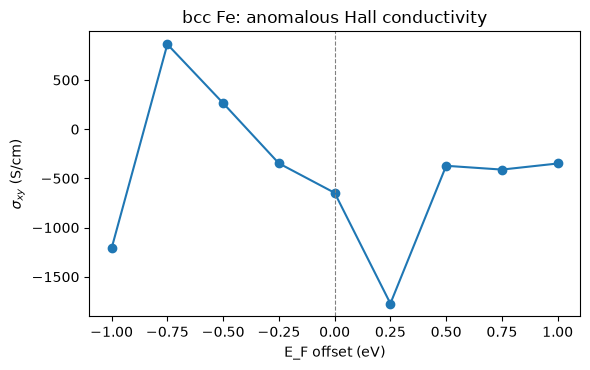

sigma_xy at E_F: -647 S/cm (experiment ~ 1000 S/cm; sensitive to mesh/E_F)


In [5]:
import time
fermis_eV = np.arange(E_FERMI - 1.0, E_FERMI + 1.01, 0.25)
t0 = time.time()
ahc = anomalous_hall_conductivity(result.hr, AA_R, RECIP, REAL,
                                  fermis_eV * EV_TO_HARTREE, mesh=(25, 25, 25))
sigma_S_cm = to_si_units(ahc.sigma, 'hall_conductivity',
                         cell_volume_bohr3=CELL_VOLUME_BOHR3)
print(f'AHC scan over {len(fermis_eV)} Fermi energies on a 25^3 mesh '
      f'({25**3} k-points): {time.time()-t0:.1f} s')

fig, ax = plt.subplots(figsize=(6, 3.8))
ax.plot(fermis_eV - E_FERMI, sigma_S_cm[:, 2], 'o-', color='C0')
ax.axvline(0.0, color='0.5', lw=0.8, ls='--')
ax.set_xlabel('E_F offset (eV)'); ax.set_ylabel(r'$\sigma_{xy}$ (S/cm)')
ax.set_title('bcc Fe: anomalous Hall conductivity')
plt.tight_layout(); plt.show()
print(f'sigma_xy at E_F: {sigma_S_cm[len(fermis_eV)//2, 2]:.0f} S/cm '
      f'(experiment ~ 1000 S/cm; sensitive to mesh/E_F)')

**Takeaway.** From a single converged SOC DFT calculation, waw builds the 18-spinor-MLWF model, the Wannier position operator, and the full postw90 `berry` workflow — Berry curvature and the anomalous Hall conductivity $\sigma^A_{xy}(E_F)$ from the full WYSV06 $J_0+J_1+J_2$ formula — waw-native and multi-core, with no `wannier90.x`.